In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


In [2]:
# Configuration and paths
corr_method = 'spearman'
trait_type = 'quantitative'
# variant_class = 'splicing'

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac

759.292

In [3]:
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""conservation""","""gpn_score""","""#942c80""","""GPN-MSA""",-1
"""conservation""","""zooverphylop""","""#6a1c81""","""Zoonomia vertebrate PhyloP""",1
…,…,…,…,…
"""regulatory""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1
"""regulatory""","""promoterai_under""","""#00A99D""","""PromoterAI under""",-1
"""regulatory""","""promoterai_over""","""#00A99D""","""PromoterAI over""",1


In [5]:
variant_class = '5utr_upstream10kb'
anno = pl.scan_parquet(f"/home/dnanexus/data_dir/variant_classes/genebass1e6_genes_10kb_{variant_class.lower()}_variants_annotated_250925.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .filter(
        (pl.col('dist_to_tss') >= -50) &
        (pl.col('dist_to_tss') <= 0)
    )
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    .fill_null(0)
    # .drop_nulls()
)

print('filtered anno')
anno

filtered anno


TSS,zooverphylop,delta_score,esmscoremissense,gene_name,verphylop,abexp_max,absplice2_max,am_pathogenicity,pangolin_score,dist_to_tss,promoterai_abs,gene_length,gpn_score,absplice_dna_max,promoterai_over,id,Strand,region,promoterai_under,abexp_min,relative_cds_position,cadd_raw,promoterai
i64,f32,f32,f32,str,f32,f64,f32,f32,f32,i64,f32,i64,f32,f32,f32,str,cat,str,f32,f64,f32,f32,f32
127526886,-1.085,0.0,0.0,"""IWS1""",-0.651,0.003182,0.0,0.0,0.0,-21,0.0652,90681,-1.12,0.0,0.0652,"""chr2:127526907:C:T""","""-""","""ENSG00000163166""",0.0,0.002221,0.0,0.400028,0.0652
136118149,2.893,0.0,0.0,"""CXCR4""",0.947,-0.000122,0.0,0.0,0.0,-10,0.0112,3802,-4.32,0.0,0.0112,"""chr2:136118159:G:A""","""-""","""ENSG00000121966""",0.0,-0.006845,0.0,1.577991,0.0112
168786538,0.586,0.0,0.0,"""NOSTRIN""",0.264,0.002469,0.0,0.0,0.0,-15,0.0147,78977,0.07,0.0,0.0,"""chr2:168786523:C:T""","""+""","""ENSG00000163072""",-0.0147,0.002469,0.0,0.233014,-0.0147
213152427,2.675,0.0,0.0,"""IKZF2""",0.75,-0.009593,0.0,0.0,0.0,0,0.0324,152738,-6.03,0.0,0.0,"""chr2:213152427:C:A""","""-""","""ENSG00000030419""",-0.0324,-0.012924,0.0,1.10133,-0.0324
127526886,0.018,0.0,0.0,"""IWS1""",-0.45,0.003182,0.0,0.0,0.0,-9,0.0208,90681,-0.29,0.0,0.0208,"""chr2:127526895:C:A""","""-""","""ENSG00000163166""",0.0,0.002221,0.0,0.392766,0.0208
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
42780609,-0.146,0.0,0.0,"""WNK4""",0.042,0.0,0.0,0.0,0.0,-27,0.0,16458,-1.46,0.0,0.0,"""chr17:42780582:T:TG""","""+""","""ENSG00000126562""",0.0,0.0,0.0,0.0,0.0
29581327,-0.146,0.0,0.0,"""NIPSNAP1""",0.042,0.0,0.0,0.0,0.0,-30,0.0,26521,-1.46,0.0,0.0,"""chr22:29581357:CTTTTTTT:C""","""-""","""ENSG00000184117""",0.0,0.0,0.0,0.0,0.0
26234987,-0.146,0.0,0.0,"""H1-3""",0.042,0.0,0.0,0.0,0.0,-30,0.0,777,-1.46,0.0,0.0,"""chr6:26235017:A:AT""","""-""","""ENSG00000124575""",0.0,0.0,0.0,0.0,0.0


In [6]:
melted_anno = anno.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
)

print('melted anno')

melted_anno['id'].n_unique(), melted_anno.shape[0]

melted anno


(61408, 1045534)

In [7]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = appv.join(
    anno_keys, on='id', how='semi'
).filter(
    pl.col('n_individuals') <= mac
)

unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()
unique_phenotypes

phenotype
str
"""ldl_direct_int"""
"""white_blood_cell_leukocyte_cou…"
"""lymphocyte_count_int"""
"""mean_time_to_correctly_identif…"
"""heel_bone_mineral_density_bmd_…"
…
"""sitting_height_int"""
"""neutrophill_percentage_int"""
"""alkaline_phosphatase_int"""


In [8]:
# Read the full Genebass results
# p-value thresholds
pval_cutoffs = {'burden': 6.7e-7, 'skato': 2.5e-7}

# Convert the pandas operations into a single Polars expression
gb_pl = (
    pl.read_parquet('/home/dnanexus/data_dir/association_files/genebass_all_associations_p_e-5.parquet')
    .with_columns(
        significant = (pl.col('Pvalue') < pval_cutoffs['skato']) | (pl.col('Pvalue_Burden') < pval_cutoffs['burden']),
        phenotype = pl.col('description').str.replace_all(r"\(", "").str.replace_all(r"\)", "").str.replace_all(' ', '_').str.replace_all('-', '').str.replace_all("'", '').str.replace_all(',', '').str.to_lowercase() + '_int',
        region = pl.col('gene_id'),
        gene_name = pl.col('gene_symbol'),
    )
    .filter(
        (pl.col('significant') == True) &
        (pl.col('trait_type') == 'continuous') &
        # (pl.col('annotation').str.contains('pLoF'))
        (pl.col('annotation') == 'pLoF')
    )
    .select(['region', 'gene_name', 'phenotype', 'trait_type'])
    .unique()
)

# Keep the top hit per gene
# gb_pl = gb_pl.sort("Pvalue").unique(subset=["region"], keep="first")

gene_trait_df = gb_pl[['region', 'gene_name', 'phenotype', 'trait_type']].unique()

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

lofcorr_df = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_EUR_genebass1e6coding_maf1e3.parquet")

gene_trait_df = gb_pl.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner')
gene_trait_df = gene_trait_df.join(lofcorr_df, on=['region', 'gene_name', 'phenotype'], how='left').with_columns(
    sign_agreement = (pl.col('loftee_corr')*pl.col('beta') > 0) & (pl.col('loftee_corr').is_not_nan()),
    corr_dir = (pl.col('loftee_corr')/pl.col('loftee_corr').abs())
)

# TODO: We don't cover all genebass significant genes, so we need to filter out nans (LOFTEE correlations missing)
gene_trait_df = gene_trait_df.filter(pl.col('sign_agreement')==1)
gene_trait_df

region,gene_name,phenotype,trait_type,beta,rvat_pval,n_variants,n_variants_nonull,n_plof_variants,loftee_corr,n_individuals_plof,top_plof_var,top_plof_var_count,plof_prop,t_stat,corr_pval,sign_agreement,corr_dir
str,str,str,str,f64,f64,u64,u64,i64,f32,list[u32],str,u32,f64,f64,f64,bool,f32
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""","""continuous""",-0.195409,9.1637e-8,1280,1280,70,-0.129833,"[62, 54, … 1]","""chr1:176710105:CG:C""",62,0.0546875,-4.681031,0.000003,true,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""","""continuous""",-0.397279,0.006626,530,530,13,-0.219682,"[1, 1, … 1]","""chr11:14493694:G:A""",1,0.024528,-5.174315,3.2549e-7,true,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""","""continuous""",-0.058463,0.000305,1098,1098,106,-0.036752,"[627, 129, … 1]","""chr14:58428357:T:TC""",627,0.096539,-1.217545,0.223659,true,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""","""continuous""",-0.436618,6.0395e-11,2030,2030,55,-0.199516,"[40, 37, … 1]","""chr15:88843601:CG:C""",40,0.027094,-9.169199,1.1354e-19,true,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""","""continuous""",-0.412619,2.8609e-8,1093,1093,46,-0.154286,"[13, 7, … 1]","""chr15:98924680:CAA:C""",13,0.042086,-5.157856,2.9651e-7,true,-1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""","""continuous""",0.952411,1.8038e-41,315,315,16,0.174576,"[149, 5, … 1]","""chr6:49636655:C:T""",149,0.050794,3.136737,0.001871,true,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""","""continuous""",0.656849,2.1682e-10,1392,1392,34,0.269449,"[18, 12, … 1]","""chr8:41672574:CTG:C""",18,0.024425,10.431616,1.3985e-24,true,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""","""continuous""",0.176348,2.1188e-7,2047,2047,225,0.035972,"[109, 67, … 1]","""chr9:77339540:C:CT""",109,0.109917,1.627776,0.103726,true,1.0


In [9]:
gene_trait_df['region'].n_unique(), gene_trait_df.shape[0]

(365, 1218)

In [10]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- 2. Build the main lazy query plan step-by-step ---
# Start by filtering 'appv', then join everything together. Every operation returns another LazyFrame.
final_lazy_plan = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .drop_nulls()
    
    # B. Join the other two dataframes
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )

    # C. Apply the ranking (window function) lazily
    .with_columns(
        pl.col(c)
        .rank("ordinal")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['mean_pheno_value', 'annotation_score']
    )

    # D. Apply the group_by and aggregation lazily
    .group_by(["region", "gene_name", "phenotype", "annotation"])
    .agg(
        pl.col("id").count().alias("n_variants"),
        pl.corr("mean_pheno_value_rank", "annotation_score_rank", propagate_nans=True).alias("correlation")
    )
    .filter(pl.col("n_variants") > 1)  # Filter groups with more than 1 variant
    
    # E. Add the final column lazily
    .with_columns(
        abs_corr = pl.col("correlation").abs()
    )
)

# --- 3. Execute the ENTIRE plan at once ---
# This is the ONLY time data is computed. The streaming engine handles the whole complex query in memory-safe chunks.
print("Executing the full lazy plan with the streaming engine...")
correlation_df = final_lazy_plan.collect(engine='streaming')

# --- 4. Join with beta directions and annotation directions ---
correlation_df = correlation_df.join(
    gene_trait_df[['region', 'phenotype', 'sign_agreement', 'corr_dir']], on=['region', 'phenotype']
).join(
    anno_config_df, on='annotation'
).with_columns(
    corr_beta = pl.col('correlation')*pl.col('corr_dir')*pl.col('annotation_dir')
)

print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Executing the full lazy plan with the streaming engine...
Final DataFrame shape: (19261, 14)


region,gene_name,phenotype,annotation,n_variants,correlation,abs_corr,sign_agreement,corr_dir,category,color,label,annotation_dir,corr_beta
str,str,str,str,u64,f64,f64,bool,f32,str,str,str,i64,f64
"""ENSG00000101745""","""ANKRD12""","""townsend_deprivation_index_at_…","""delta_score""",21,-0.202597,0.202597,true,1.0,"""splicing""","""#00A99D""","""SpliceAI""",1,-0.202597
"""ENSG00000105610""","""KLF1""","""haematocrit_percentage_int""","""absplice2_max""",5,0.9,0.9,true,-1.0,"""splicing""","""#1E8449""","""AbSplice2 (max)""",1,-0.9
"""ENSG00000167676""","""PLIN4""","""trunk_fat_percentage_int""","""absplice2_max""",14,-0.059341,0.059341,true,-1.0,"""splicing""","""#1E8449""","""AbSplice2 (max)""",1,0.059341
"""ENSG00000004939""","""SLC4A1""","""total_bilirubin_int""","""promoterai_over""",11,-0.254545,0.254545,true,1.0,"""regulatory""","""#00A99D""","""PromoterAI over""",1,-0.254545
"""ENSG00000089327""","""FXYD5""","""trunk_fatfree_mass_int""","""promoterai_under""",10,0.636364,0.636364,true,-1.0,"""regulatory""","""#00A99D""","""PromoterAI under""",-1,0.636364
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000152270""","""PDE3B""","""reticulocyte_count_int""","""delta_score""",16,-0.179412,0.179412,true,-1.0,"""splicing""","""#00A99D""","""SpliceAI""",1,0.179412
"""ENSG00000140443""","""IGF1R""","""whole_body_fatfree_mass_int""","""promoterai_over""",47,0.223867,0.223867,true,-1.0,"""regulatory""","""#00A99D""","""PromoterAI over""",1,-0.223867
"""ENSG00000112077""","""RHAG""","""mean_reticulocyte_volume_int""","""delta_score""",7,0.0,0.0,true,-1.0,"""splicing""","""#00A99D""","""SpliceAI""",1,-0.0


In [11]:
(
    correlation_df
    # .drop_nans()
    .select(['region', 'gene_name', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .sort('n_associations')
)

annotation,n_associations
str,u64
"""gpn_score""",1133
"""abexp_min""",1133
"""promoterai_over""",1133
"""pangolin_score""",1133
"""zooverphylop""",1133
…,…
"""esmscoremissense""",1133
"""delta_score""",1133
"""promoterai""",1133


In [12]:
# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    correlation_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Inconsistent (region, phenotype) pairs: 0


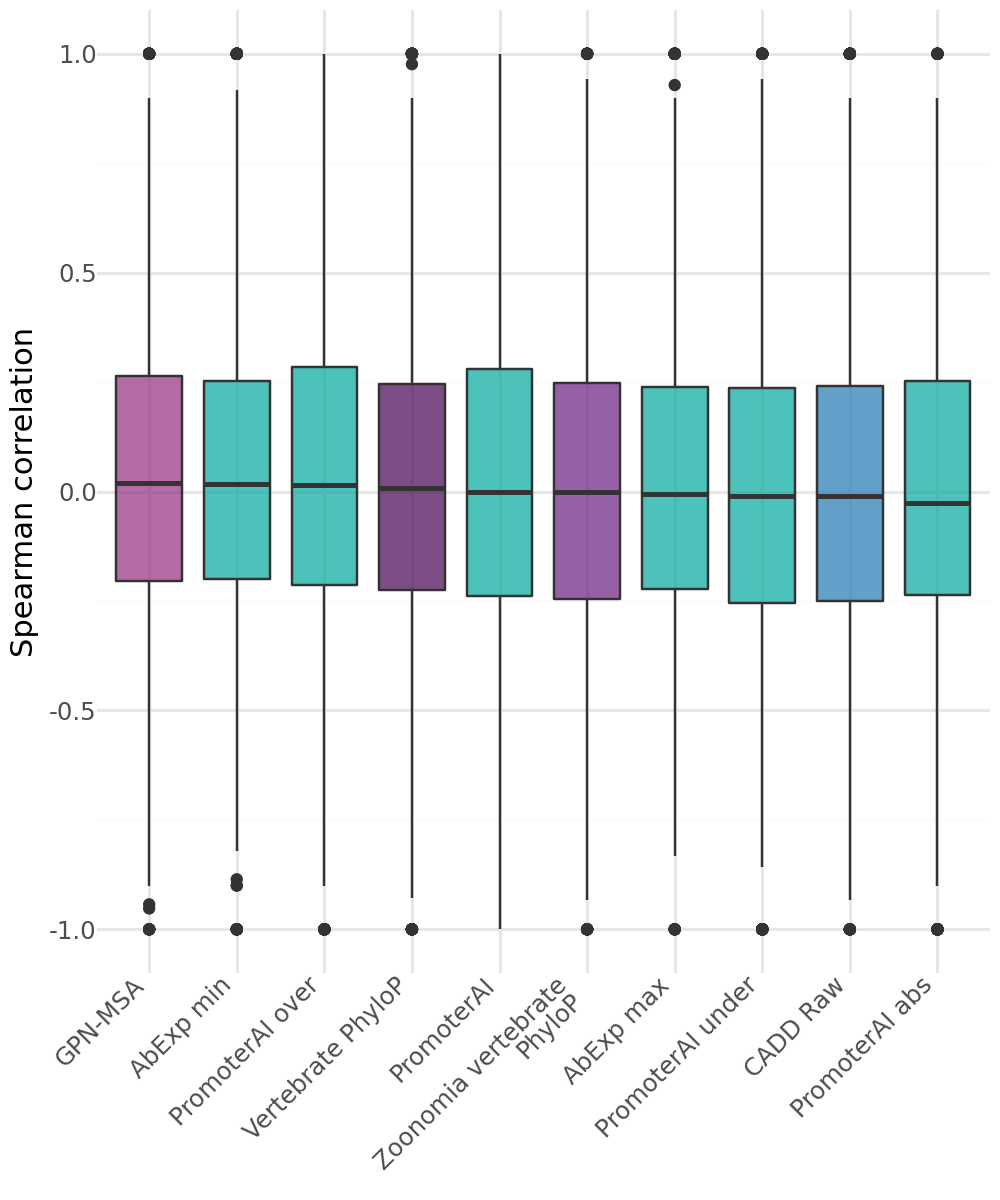

In [13]:
# Filter to only those with sign agreement
filt_corr_df = correlation_df.filter(~pl.col('category').is_in(['missense', 'plof', 'naive', 'splicing']))#.drop_nans()

med_df = filt_corr_df.drop_nans().group_by("annotation").agg([
    pl.col("corr_beta").median().alias("median_abs_corr"),
])

corr_pd = med_df.join(filt_corr_df, on='annotation').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_abs_corr', ascending=False)['label'].unique(),
    ordered=True
)

color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x="label", y="corr_beta", fill="annotation")) +
    geom_boxplot(alpha=0.7) +
    theme_minimal() +
    scale_fill_manual(values=color_dict) +
    # lims(
    #     y=(-0.5, 0.5)
    # ) +
    labs(
        x="",
        y="Spearman correlation"
    ) +
    theme(
        figure_size=(5, 6),
        legend_position="none",
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

In [14]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")

/tmp/ipykernel_21178/3626945958.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""gpn_score""","""cadd_raw""",1133,255806.5,0.00331
"""gpn_score""","""promoterai_abs""",1133,279592.0,0.004623
"""promoterai_over""","""promoterai_abs""",1133,249017.0,0.00626
"""gpn_score""","""zooverphylop""",1133,264726.0,0.00811
"""promoterai_over""","""promoterai""",1133,209392.5,0.020556


# Single gene-trait association plots

In [ ]:
## Single gene-trait association plot
method = 'pearson'
annotation = 'gpn_score'
gene_name = 'LDLR'
phenotype = 'ldl_direct_int'
final_lazy_plan = (
    appv
    .filter(pl.col('phenotype') == phenotype)
    .join(anno_ids_lazy, on="id", how="semi")
    .drop_nulls()
    
    # B. Join the other two dataframes
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
)


sc_df = pheno_anno.filter(
    (pl.col('phenotype') == phenotype) &
    (pl.col('gene_name') == gene_name) &
    (pl.col('annotation') == annotation)
)

(
    ggplot(sc_df, aes(x='annotation_score', y='mean_pheno_value')) +
    geom_point(alpha=0.25) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x=f"{annotation}",
        y=f"{phenotype} residual"
    ) +
    theme(figure_size=(5, 4))
)